## Data Preprocessing — Customer Churn Classification

Pipeline: Drop ID → Handle Missing → Encode Categoricals → Feature Engineering → Split → Scale

### Imports & Load Data

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler

train = pd.read_csv("/content/data/churn_train.csv")
test = pd.read_csv("/content/data/churn_test.csv")

train_df = train
print(f"Train shape: {train_df.shape}")


Train shape: (440833, 12)


### 1. Drop cột không cần thiết

- `CustomerID` là cột định danh, không mang thông tin dự đoán
- Nếu giữ lại, model sẽ "memorize" ID → overfitting

In [30]:
drop_cols = ["CustomerID"]

train_df = train_df.drop(columns=drop_cols)

print(f"Train columns: {train_df.columns.tolist()}")
print(f"Train shape sau khi drop: {train_df.shape}")

Train columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
Train shape sau khi drop: (440833, 11)


### 2. Xử lý Missing Values

- Train có đúng **1 dòng** (index 199295) tất cả cột đều null
- Test **không có** missing values


In [31]:
# Kiểm tra missing trước khi xử lý
print(f"Train missing rows: {train_df.isnull().any(axis=1).sum()}")

# Drop dòng missing
train_df = train_df.dropna()

# Reset index
train_df = train_df.reset_index(drop=True)

print("--- Sau Khi Xử Lý ---")
print(f"Train shape: {train_df.shape}")
print(f"Train missing: {train_df.isnull().sum().sum()}")

Train missing rows: 1
--- Sau Khi Xử Lý ---
Train shape: (440832, 11)
Train missing: 0


### 3. Encode Categorical Features

| Cột | Giá trị | Phương pháp | Lý do |
|-----|---------|-------------|-------|
| `Gender` | Female, Male | LabelEncoder | Binary → 0/1 |
| `Subscription Type` | Basic, Standard, Premium | OrdinalEncoder | Có thứ bậc tự nhiên |
| `Contract Length` | Monthly, Quarterly, Annual | OrdinalEncoder | Có thứ bậc tự nhiên |

In [32]:
# Kiểm tra các giá trị unique trước khi encode
print("Gender:", train_df["Gender"].unique())
print("Subscription Type:", train_df["Subscription Type"].unique())
print("Contract Length:", train_df["Contract Length"].unique())

Gender: ['Female' 'Male']
Subscription Type: ['Standard' 'Basic' 'Premium']
Contract Length: ['Annual' 'Monthly' 'Quarterly']


In [33]:
# --- Gender: Binary → LabelEncoder ---
le_gender = LabelEncoder()
train_df["Gender"] = le_gender.fit_transform(train_df["Gender"])

print(f"Gender mapping: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


In [34]:
# --- Subscription Type: Ordinal (Basic = 0 < Standard = 1 < Premium = 2) ---
sub_categories = [["Basic", "Standard", "Premium"]]
oe_sub = OrdinalEncoder(categories=sub_categories)

train_df["Subscription Type"] = oe_sub.fit_transform(train_df[["Subscription Type"]])

print(f"Subscription Type mapping: Basic=0, Standard=1, Premium=2")
print(f"Unique values: {sorted(train_df['Subscription Type'].unique())}")

Subscription Type mapping: Basic=0, Standard=1, Premium=2
Unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [35]:
# --- Contract Length: Ordinal (Monthly=0 < Quarterly=1 < Annual=2) ---
contract_categories = [["Monthly", "Quarterly", "Annual"]]
oe_contract = OrdinalEncoder(categories=contract_categories)

train_df["Contract Length"] = oe_contract.fit_transform(train_df[["Contract Length"]])

print(f"Contract Length mapping: Monthly=0, Quarterly=1, Annual=2")
print(f"Unique values: {sorted(train_df['Contract Length'].unique())}")

Contract Length mapping: Monthly=0, Quarterly=1, Annual=2
Unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [36]:
# Kiểm tra toàn bộ dtypes sau khi encode
print("=== Data types sau encoding ===")
print(train_df.dtypes)
print(f"\nTrain shape: {train_df.shape}")
train_df.head()

=== Data types sau encoding ===
Age                  float64
Gender                 int64
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type    float64
Contract Length      float64
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

Train shape: (440832, 11)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,1.0,2.0,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,0.0,0.0,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,0.0,1.0,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,1.0,0.0,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,0.0,0.0,617.0,20.0,1.0


### 4. Feature Engineering

Tạo các feature mới dựa trên domain knowledge:

| Feature | Công thức | Ý nghĩa |
|---------|----------|----------|
| `Spend_per_Tenure` | Total Spend / Tenure | Chi tiêu TB mỗi tháng |
| `Usage_per_Tenure` | Usage Frequency / Tenure | Mức sử dụng theo thời gian |
| `Support_per_Tenure` | Support Calls / Tenure | Tần suất gọi support |
| `Delay_x_Support` | Payment Delay × Support Calls | Risk interaction feature |

In [37]:
def add_features(df):
    """Tạo các features mới cho DataFrame."""
    df = df.copy()

    # Chi tiêu trung bình mỗi nhiệm kỳ
    df["Spend_per_Tenure"] = df["Total Spend"] / df["Tenure"]

    # Mức sử dụng dịch vụ theo thời gian
    df["Usage_per_Tenure"] = df["Usage Frequency"] / df["Tenure"]

    # Tần suất liên hệ hỗ trợ theo thời gian
    df["Support_per_Tenure"] = df["Support Calls"] / df["Tenure"]

    # Interaction: khách hàng vừa trễ hạn vừa gọi support nhiều => risk cao
    df["Delay_x_Support"] = df["Payment Delay"] * df["Support Calls"]

    return df

train_df = add_features(train_df)

print(f"Train shape sau feature engineering: {train_df.shape}")
print(f"\nCác cột mới: {train_df.columns.tolist()[-4:]}")
train_df.head()

Train shape sau feature engineering: (440832, 15)

Các cột mới: ['Spend_per_Tenure', 'Usage_per_Tenure', 'Support_per_Tenure', 'Delay_x_Support']


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Spend_per_Tenure,Usage_per_Tenure,Support_per_Tenure,Delay_x_Support
0,30.0,0,39.0,14.0,5.0,18.0,1.0,2.0,932.0,17.0,1.0,23.897436,0.358974,0.128205,90.0
1,65.0,0,49.0,1.0,10.0,8.0,0.0,0.0,557.0,6.0,1.0,11.367347,0.020408,0.204082,80.0
2,55.0,0,14.0,4.0,6.0,18.0,0.0,1.0,185.0,3.0,1.0,13.214286,0.285714,0.428571,108.0
3,58.0,1,38.0,21.0,7.0,7.0,1.0,0.0,396.0,29.0,1.0,10.421053,0.552632,0.184211,49.0
4,23.0,1,32.0,20.0,5.0,8.0,0.0,0.0,617.0,20.0,1.0,19.281250,0.625000,0.156250,40.0


In [38]:
# Kiểm tra có inf hay NaN sau feature engineering không
print("--- Kiểm tra giá trị bất thường ---")
print(f"Inf values in train: {np.isinf(train_df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"NaN values in train: {train_df.isnull().sum().sum()}")

--- Kiểm tra giá trị bất thường ---
Inf values in train: 0
NaN values in train: 0


### 5. Tách dữ liệu: Train / Validation / Test

- **Train** (80%): huấn luyện model
- **Validation** (20%): đánh giá & tune hyperparameters
- **Test**: đánh giá cuối cùng (chỉ dùng 1 lần)
- Dùng `stratify` để giữ tỷ lệ class balance

In [39]:
# Tách features và target
TARGET = "Churn"

X_train_full = train_df.drop(columns=[TARGET])
y_train_full = train_df[TARGET]

# Lưu tên features để dùng cho feature importance
feature_names = X_train_full.columns.tolist()
print(f"Feature names ({len(feature_names)}): {feature_names}")

Feature names (14): ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Spend_per_Tenure', 'Usage_per_Tenure', 'Support_per_Tenure', 'Delay_x_Support']


In [40]:
# Split: 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    # giữ tỉ lệ Churn/Not Churn
    stratify=y_train_full
)

print(f"X_train: {X_train.shape} | y_train Churn ratio: {y_train.mean():.4f}")
print(f"X_val:  {X_val.shape}  | y_val Churn ratio:  {y_val.mean():.4f}")

X_train: (352665, 14) | y_train Churn ratio: 0.5671
X_val:  (88167, 14)  | y_val Churn ratio:  0.5671


### 6. Feature Scaling

- Dùng `StandardScaler`: chuẩn hóa về mean=0, std=1


In [41]:
scaler = StandardScaler()

# chỉ fit trên tập train để tránh data leakage
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

print("=== Thống kê X_train sau scaling ===")
print(X_train_scaled.describe().round(4))

=== Thống kê X_train sau scaling ===
               Age       Gender       Tenure  Usage Frequency  Support Calls  \
count  352665.0000  352665.0000  352665.0000      352665.0000    352665.0000   
mean        0.0000       0.0000      -0.0000           0.0000        -0.0000   
std         1.0000       1.0000       1.0000           1.0000         1.0000   
min        -1.7181      -1.1467      -1.7520          -1.7266        -1.1738   
25%        -0.8342      -1.1467      -0.8829          -0.7947        -0.8482   
50%        -0.0307       0.8721       0.0441           0.0206        -0.1972   
75%         0.6925       0.8721       0.8553           0.8359         0.7794   
max         2.0585       0.8721       1.6664           1.6512         2.0816   

       Payment Delay  Subscription Type  Contract Length  Total Spend  \
count    352665.0000        352665.0000      352665.0000  352665.0000   
mean          0.0000             0.0000           0.0000      -0.0000   
std           1.0000   

### 8. Tổng Kết

In [42]:
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"\n Dataset sizes:")
print(f"   Train:      {X_train_scaled.shape}")
print(f"   Validation:       {X_val_scaled.shape}")
print(f"\n Features ({len(feature_names)}):")
for i, feat in enumerate(feature_names, 1):
    print(f"   {i:2d}. {feat}")
print(f"\n Target: Churn (binary)")
print(f"   Train Churn ratio:  {y_train.mean():.4f}")
print(f"   Validation Churn ratio:   {y_val.mean():.4f}")
print(f"\n Missing values: 0")

PREPROCESSING SUMMARY

 Dataset sizes:
   Train:      (352665, 14)
   Validation:       (88167, 14)

 Features (14):
    1. Age
    2. Gender
    3. Tenure
    4. Usage Frequency
    5. Support Calls
    6. Payment Delay
    7. Subscription Type
    8. Contract Length
    9. Total Spend
   10. Last Interaction
   11. Spend_per_Tenure
   12. Usage_per_Tenure
   13. Support_per_Tenure
   14. Delay_x_Support

 Target: Churn (binary)
   Train Churn ratio:  0.5671
   Validation Churn ratio:   0.5671

 Missing values: 0


---

### Ghi chú cho bước tiếp theo (Model Training)

Các biến sẵn sàng để sử dụng:
- `X_train_scaled`, `y_train` → Huấn luyện model
- `X_val_scaled`, `y_val` → Đánh giá
- `feature_names` → Tên các features (cho feature importance)
- `scaler` → Scaler object (cần save để dùng cho inference)

## Modeling — Using Deep learning

### Import libraries

In [43]:
!pip install pytorch-tabnet

In [44]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from pytorch_tabnet.tab_model import TabNetClassifier

### Define Hyperparameters

In [45]:
EPOCHS = 100
BATCH_SIZE = 256
LR = 0.0001

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}")

Using cuda


### Define dataset

In [46]:
X_train_scaled, y_train = X_train_scaled.to_numpy(), y_train.to_numpy()
X_val_scaled, y_val = X_val_scaled.to_numpy(), y_val.to_numpy()

In [47]:
class ChurnDataset(Dataset):
    def __init__(self, X, y) -> None:
        super().__init__()
        self.X = torch.tensor(X, dtype=torch.float).to(device)
        self.y = torch.tensor(y, dtype=torch.float).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [48]:
train_churn_dataset = ChurnDataset(X_train_scaled, y_train)
val_churn_dataset = ChurnDataset(X_val_scaled, y_val)

train_loader = DataLoader(train_churn_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_churn_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Define models

Baseline: Input(14) -> Hidden(64) -> Hidden(32) -> Output(1)

In [49]:
class BaseNeuralNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, output_dim),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.fc(input)

In [50]:
clf = TabNetClassifier(
    n_d=16, n_a=16,
    n_steps=3,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size":10, "gamma":0.9},
    mask_type='entmax'
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


#Train models

In [55]:
base_nn = BaseNeuralNetwork(14, 1).to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(base_nn.parameters(), lr=LR)

In [56]:
def train_and_val_loop(train_loader, val_loader, model, loss_fn, optimizer):
    train_losses, val_losses = [], []

    for i in range(EPOCHS):
        model.train()
        running_loss = 0.0

        print(f"------------------EPOCH {i+1}:------------------")
        for batch, (X, y) in enumerate(train_loader):
            y_pred = model(X)
            y_pred = y_pred.squeeze()
            loss = loss_fn(y_pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Loss: {avg_loss:>7f}")
        train_losses.append(avg_loss)

        val_loss = val_loop(val_loader, model, loss_fn)
        val_losses.append(val_loss)

    return train_losses, val_losses

def val_loop(data_loader, model, loss_fn):
    num_batches = len(data_loader)
    size = len(data_loader.dataset)
    total_loss, correct = 0, 0

    model.eval()
    with torch.no_grad():
      for X, y in data_loader:
          y_pred = model(X)
          y_pred = y_pred.squeeze()
          loss = loss_fn(y_pred, y)

          total_loss += loss.item()
          predictions = (y_pred >= 0.5).float()
          correct += (predictions == y).float().sum().item()

    total_loss /= num_batches
    correct /= size
    print(f"Validation : \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {total_loss:>8f} \n")
    return total_loss

In [57]:
train_losses, val_losses = train_and_val_loop(train_loader, val_loader, base_nn, loss_fn, optimizer)

------------------EPOCH 1:------------------
Loss: 0.361758
Validation : 
 Accuracy: 90.7%, Avg loss: 0.228122 

------------------EPOCH 2:------------------
Loss: 0.180144
Validation : 
 Accuracy: 95.0%, Avg loss: 0.141237 

------------------EPOCH 3:------------------
Loss: 0.119498
Validation : 
 Accuracy: 96.2%, Avg loss: 0.106702 

------------------EPOCH 4:------------------
Loss: 0.098241
Validation : 
 Accuracy: 96.6%, Avg loss: 0.093268 

------------------EPOCH 5:------------------
Loss: 0.088114
Validation : 
 Accuracy: 96.9%, Avg loss: 0.085225 

------------------EPOCH 6:------------------
Loss: 0.081154
Validation : 
 Accuracy: 97.1%, Avg loss: 0.078735 

------------------EPOCH 7:------------------
Loss: 0.075522
Validation : 
 Accuracy: 97.3%, Avg loss: 0.073436 

------------------EPOCH 8:------------------
Loss: 0.070667
Validation : 
 Accuracy: 97.5%, Avg loss: 0.068521 

------------------EPOCH 9:------------------
Loss: 0.066268
Validation : 
 Accuracy: 97.7%, Avg 

In [58]:
clf.fit(
    X_train=X_train_scaled, y_train=y_train,
    eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
    eval_name=['train', 'val'],
    eval_metric=['logloss', 'auc', 'accuracy'],
    max_epochs=EPOCHS,
    patience=15,
    batch_size=BATCH_SIZE,
    drop_last=False
)

epoch 0  | loss: 0.0694  | train_logloss: 0.04317 | train_auc: 0.99682 | train_accuracy: 0.98738 | val_logloss: 0.04215 | val_auc: 0.99727 | val_accuracy: 0.9874  |  0:00:51s
epoch 1  | loss: 0.05529 | train_logloss: 0.04242 | train_auc: 0.99772 | train_accuracy: 0.98723 | val_logloss: 0.04118 | val_auc: 0.9979  | val_accuracy: 0.98732 |  0:01:42s
epoch 2  | loss: 0.05288 | train_logloss: 0.03241 | train_auc: 0.9981  | train_accuracy: 0.99002 | val_logloss: 0.03112 | val_auc: 0.99835 | val_accuracy: 0.99018 |  0:02:34s
epoch 3  | loss: 0.05124 | train_logloss: 0.03959 | train_auc: 0.99762 | train_accuracy: 0.98858 | val_logloss: 0.03907 | val_auc: 0.9977  | val_accuracy: 0.98883 |  0:03:25s
epoch 4  | loss: 0.0508  | train_logloss: 0.04327 | train_auc: 0.99789 | train_accuracy: 0.98639 | val_logloss: 0.04301 | val_auc: 0.99819 | val_accuracy: 0.98606 |  0:04:17s
epoch 5  | loss: 0.0505  | train_logloss: 0.04005 | train_auc: 0.99798 | train_accuracy: 0.9881  | val_logloss: 0.03864 | val

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


### Evaluate

100 100


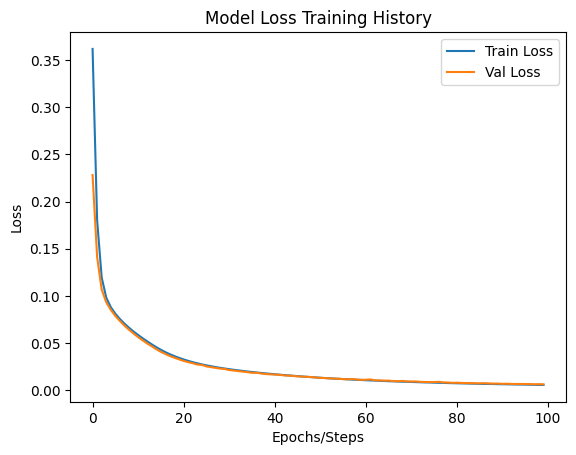

In [59]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

print(len(train_losses), len(val_losses))

plt.title('Model Loss Training History')
plt.xlabel('Epochs/Steps')
plt.ylabel('Loss')
plt.legend()
plt.show()

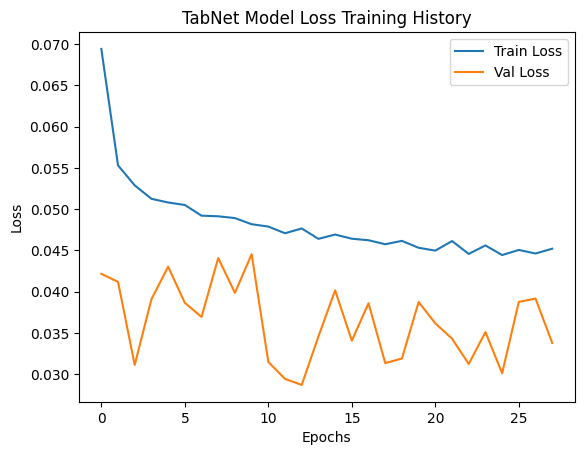

In [60]:
plt.plot(clf.history['loss'], label='Train Loss', color='#1f77b4')
plt.plot(clf.history['val_logloss'], label='Val Loss', color='#ff7f0e')

plt.title('TabNet Model Loss Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()